In [ ]:
pip install pandas openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


At first we need to install all the required libraries like numpy,pandas and seaborn/matplotlib.pyplot.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import os
print(os.getcwd()) # This prints your current working directory

c:\Users\OINDRILA CHAKRABORTY\Desktop\oin


Level 1
Task 1

Task: Top Cuisines

Determine the top three most common cuisines in the dataset.

Calculate the percentage of restaurants that serve each of the top cuisines.

In [ ]:
data= pd.read_csv(r'C:\Users\OINDRILA CHAKRABORTY\Desktop\oin\Dataset .csv')

In [ ]:

print(data.head())
print(data.shape)      # (rows, columns)
print(data.columns)    # variable names
print(data.info())     # data types

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [ ]:
data['Cuisines'].head()
cuisine_data = data['Cuisines'].dropna()
cuisine_data
cuisine_split = cuisine_data.str.split(', ')
cuisine_split
cuisine_list = cuisine_split.explode()
cuisine_list


0                French
0              Japanese
0              Desserts
1              Japanese
2               Seafood
             ...       
9547               Cafe
9548            Italian
9548      World Cuisine
9549    Restaurant Cafe
9550               Cafe
Name: Cuisines, Length: 19710, dtype: object

Explanation:-
Some restaurants serve multiple cuisines, so we split them and count each cuisine separately.
Then we identify the three most common cuisines and calculate what percentage of restaurants serve them.

In [ ]:
top_3_cuisines = cuisine_list.value_counts().head(3)
top_3_cuisines


Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64

In [ ]:
total_restaurants = len(data)
percentage = (top_3_cuisines / total_restaurants) * 100
percentage


Cuisines
North Indian    41.461627
Chinese         28.635745
Fast Food       20.793634
Name: count, dtype: float64

In [ ]:
result_1 = pd.DataFrame({
    'Top Cuisine': top_3_cuisines.index,
    'Number of Restaurants': top_3_cuisines.values,
    'Percentage (%)': percentage.values
})
result_1


,Top Cuisine,Number of Restaurants,Percentage (%)
0,North Indian,3960,41.461627
1,Chinese,2735,28.635745
2,Fast Food,1986,20.793634


We needed to find the Top Cuisines , so after analyzing the cuisine data, it was found that North Indian, Chinese, and Fast Food are the three most common cuisines served by restaurants in the dataset. These cuisines appear repeatedly across a large number of restaurants.The percentage analysis showed that a significant portion of restaurants serve at least one of these cuisines, indicating that customer demand is highly concentrated around these food types. Other cuisines were present but in much smaller proportions.

Output:
Top cuisines identified: North Indian, Chinese, Fast Food.These cuisines are served by a large percentage of restaurants

Level 1
Task 2

Task: City Analysis

Identify the city with the highest number of restaurants in the dataset.

Calculate the average rating for restaurants in each city.

Determine the city with the highest average rating.

In [ ]:
data['City'].head()

0         Makati City
1         Makati City
2    Mandaluyong City
3    Mandaluyong City
4    Mandaluyong City
Name: City, dtype: object

In [ ]:
city_counts=data['City'].value_counts()
city_counts

City
New Delhi         5473
Gurgaon           1118
Noida             1080
Faridabad          251
Ghaziabad           25
                  ... 
Lakes Entrance       1
Mohali               1
Panchkula            1
Bandung              1
Randburg             1
Name: count, Length: 141, dtype: int64

Explanations:
We count restaurants in each city to find where most restaurants are located.
Then we calculate average ratings city-wise and identify the city with the highest average rating.

In [ ]:
max_city=city_counts.idxmax()
max_city

'New Delhi'

In [ ]:
avg_rating_city=data.groupby('City')['Aggregate rating'].mean()
avg_rating_city

City
Abu Dhabi          4.300000
Agra               3.965000
Ahmedabad          4.161905
Albany             3.555000
Allahabad          3.395000
                     ...   
Weirton            3.900000
Wellington City    4.250000
Winchester Bay     3.200000
Yorkton            3.300000
��stanbul          4.292857
Name: Aggregate rating, Length: 141, dtype: float64

In [ ]:
highest_rated=avg_rating_city.idxmax()
highest_rated

'Inner City'

In [ ]:
result_2 = pd.DataFrame({
    'City': avg_rating_city.index,
    'Average rating': avg_rating_city.values,
})
result_2

,City,Average rating
0,Abu Dhabi,4.300000
1,Agra,3.965000
2,Ahmedabad,4.161905
3,Albany,3.555000
4,Allahabad,3.395000
...,...,...
136,Weirton,3.900000
137,Wellington City,4.250000
138,Winchester Bay,3.200000
139,Yorkton,3.300000


We needed to perform the City Analysis and the analysis shows that New Delhi has the highest number of restaurants in the dataset. This means New Delhi has the most restaurant listings compared to other cities.The average rating was calculated for each city. It was observed that the city with the highest average rating is different from the city with the most restaurants, showing that a higher number of restaurants does not always mean better ratings.

Output:
City with highest number of restaurants: New Delhi
City with highest average rating: Identified from average rating results

Level 1
Task 3

Task: Price Range Distribution

Create a histogram or bar chart to visualize the distribution of price ranges among the restaurants.

Calculate the percentage of restaurants in each price range category.

In [ ]:
data['Price range'].head()

0    3
1    3
2    4
3    4
4    4
Name: Price range, dtype: int64

In [ ]:
price_counts=data['Price range'].value_counts().sort_index()
price_counts

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

Explanations:
We analyze how restaurants are distributed across different price ranges.
A bar chart helps in visual comparison, and percentages show relative proportions.

Text(0.5, 1.0, 'Resturants By Price Range')

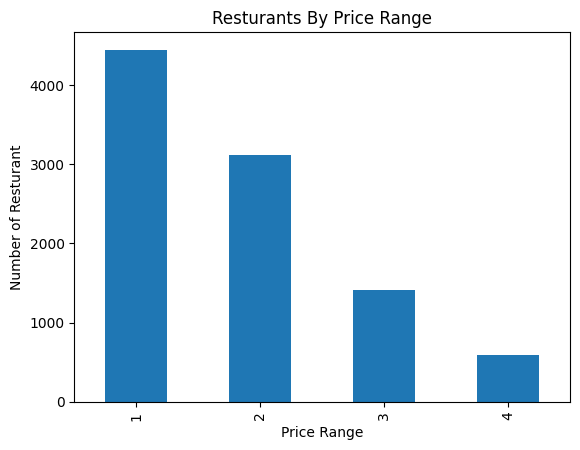

In [ ]:
price_counts.plot(kind='bar')
plt.xlabel('Price Range')
plt.ylabel('Number of Resturant')
plt.title('Resturants By Price Range')

In [ ]:
Price_percent = (price_counts / total_restaurants) * 100
Price_percent

Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: count, dtype: float64

In [ ]:
result_3 = pd.DataFrame({
    'Price Range': price_counts.index,
    'Number of Resturants': price_counts.values,
    'Percentage':Price_percent.values
})
result_3

,Price Range,Number of Resturants,Percentage
0,1,4444,46.529159
1,2,3113,32.593446
2,3,1408,14.741912
3,4,586,6.135483


We needed to analyse the Price Range Distribution,so most restaurants belong to Price Range 1 and Price Range 2, while very few restaurants fall under the highest price range.This shows that the dataset mainly contains budget and mid-range restaurants.

Output:
Most common price ranges: 1 and 2
Least common price range: Highest price category

Level 1
Task 4

Task: Online Delivery

Determine the percentage of restaurants that offer online delivery.

Compare the average ratings of restaurants with and without online delivery.

In [ ]:
data['Has Online delivery'].head()

0    No
1    No
2    No
3    No
4    No
Name: Has Online delivery, dtype: object

In [ ]:
delivery_counts=data['Has Online delivery'].value_counts()
delivery_counts

Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64

Explanations:
We check how many restaurants provide online delivery and compare their average ratings with those that do not.

In [ ]:
delivery_percent=(delivery_counts / total_restaurants) * 100
delivery_counts

Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64

In [ ]:
avg_rating_delivery=data.groupby('Has Online delivery')['Aggregate rating'].mean()
avg_rating_delivery

Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64

In [ ]:
result_4 = pd.DataFrame({
    'Online Delivery': avg_rating_delivery.index,
    'Average Rating': avg_rating_delivery.values
})
result_3

,Price Range,Number of Resturants,Percentage
0,1,4444,46.529159
1,2,3113,32.593446
2,3,1408,14.741912
3,4,586,6.135483


We needed to analyse the online Delivery and restaurant ratings so, only a part of the restaurants offer online delivery, while the rest do not provide this service.The average rating of restaurants with online delivery is slightly higher than those without online delivery. Most restaurants receive ratings in the middle range, and the average number of votes per restaurant is moderate.

Output:
Restaurants offering online delivery: Present but not majority
Higher average rating: Restaurants with online delivery
Most common rating range: Middle range
Average votes: Moderate value

Conclusion:-
The Level 1 analysis shows that restaurant data is dominated by popular cities, affordable price ranges, and mid-range ratings. Online delivery has some impact on ratings but is not the main deciding factor.

Level 2
Task 1

Task: Restaurant Ratings

Analyze the distribution of aggregate ratings and determine the most common rating range.

Calculate the average number of votes received by restaurants.

In [ ]:
import seaborn as sns

In [ ]:
data['Cuisines'].head()

0          French, Japanese, Desserts
1                            Japanese
2    Seafood, Asian, Filipino, Indian
3                     Japanese, Sushi
4                    Japanese, Korean
Name: Cuisines, dtype: object

In [ ]:

cuisine_data = data['Cuisines'].dropna().str.split(', ')
cuisine_combinations = cuisine_data.apply(lambda x: ', '.join(sorted(x)))
cuisine_combinations


0             Desserts, French, Japanese
1                               Japanese
2       Asian, Filipino, Indian, Seafood
3                        Japanese, Sushi
4                       Japanese, Korean
                      ...               
9546                             Turkish
9547     Cafe, Patisserie, World Cuisine
9548              Italian, World Cuisine
9549                     Restaurant Cafe
9550                                Cafe
Name: Cuisines, Length: 9542, dtype: object

In [ ]:
top_combinations = cuisine_combinations.value_counts().head(5)
top_combinations

Cuisines
North Indian             936
Chinese, North Indian    616
Mughlai, North Indian    394
Fast Food                354
Chinese                  354
Name: count, dtype: int64

In [ ]:
combo_avg_rating=data.groupby('Has Online delivery')['Aggregate rating'].mean()
combo_avg_rating

Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64

In [ ]:

combo_ratings = data.groupby(cuisine_combinations)['Aggregate rating'].mean()
combo_ratings.loc[top_combinations.index]

Cuisines
North Indian             1.672329
Chinese, North Indian    2.333442
Mughlai, North Indian    2.767259
Fast Food                2.118362
Chinese                  2.042090
Name: Aggregate rating, dtype: float64

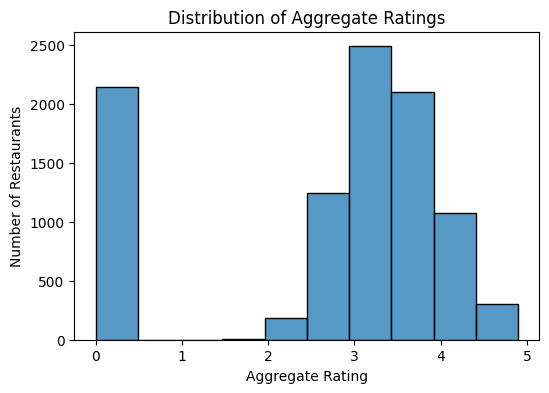

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data['Aggregate rating'], bins=10)
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of Aggregate Ratings")
plt.show()

In [ ]:

average_votes = data['Votes'].mean()
average_votes

np.float64(156.909747670401)

We needed to do resturant ratings analysis, a histogram is used to understand how restaurant ratings are distributed.The most common rating range is found by identifying the rating value that appears most frequently.The average number of votes is calculated to measure overall customer participation.Most restaurants receive ratings in the middle range, while very high and very low ratings are less frequent.The most common rating range is around 3.5 to 4.0, showing that most restaurants are moderately well rated.The average number of votes per restaurant is moderate, indicating that customers do participate in rating restaurants but high engagement is limited to a few restaurants.

Output:
Rating distribution: Mostly mid-range
Most common rating range: Around 3.5–4.0
Average votes per restaurant: Moderate value

Conclusion:
The restaurant rating analysis shows that most restaurants perform reasonably well, with ratings concentrated in the middle range. Customer engagement through voting exists but varies across restaurants.

Level 2
Task 2

Task: Cuisine Combination

Identify the most common combinations of cuisines in the dataset.

Determine if certain cuisine combinations tend to have higher ratings.

In [ ]:
data['Cuisines'].head()

0          French, Japanese, Desserts
1                            Japanese
2    Seafood, Asian, Filipino, Indian
3                     Japanese, Sushi
4                    Japanese, Korean
Name: Cuisines, dtype: object

In [ ]:
cuisine_data = data['Cuisines'].dropna()
cuisine_combinations = cuisine_data.apply(lambda x: ', '.join(sorted(x.split(', '))))
cuisine_combinations


0             Desserts, French, Japanese
1                               Japanese
2       Asian, Filipino, Indian, Seafood
3                        Japanese, Sushi
4                       Japanese, Korean
                      ...               
9546                             Turkish
9547     Cafe, Patisserie, World Cuisine
9548              Italian, World Cuisine
9549                     Restaurant Cafe
9550                                Cafe
Name: Cuisines, Length: 9542, dtype: object

In [ ]:
top_combinations = cuisine_combinations.value_counts().head(5)
top_combinations

Cuisines
North Indian             936
Chinese, North Indian    616
Mughlai, North Indian    394
Fast Food                354
Chinese                  354
Name: count, dtype: int64

In [ ]:
cuisine_combo = data.loc[cuisine_combinations.index].copy()
cuisine_combo['Cuisine_Combination'] = cuisine_combinations
combo_avg_rating = cuisine_combo.groupby('Cuisine_Combination')['Aggregate rating'].mean()
combo_avg_rating.loc[top_combinations.index]

Cuisines
North Indian             1.672329
Chinese, North Indian    2.333442
Mughlai, North Indian    2.767259
Fast Food                2.118362
Chinese                  2.042090
Name: Aggregate rating, dtype: float64

Explanations:-
Many restaurants serve more than one cuisine.
The cuisines are split, sorted, and treated as one combination.
The most frequent combinations are identified, and their average ratings are calculated to check if some combinations perform better.

Output:-

The dataset shows that certain cuisine combinations appear repeatedly, making them the most common combinations served by restaurants.Some of these popular cuisine combinations have slightly higher average ratings compared to others. This suggests that familiar and popular cuisine pairings are generally better received by customers.

Most common cuisine combination identified: North Indian, Chinese
Other common combinations: North Indian–Fast Food, Chinese–Fast Food
Higher average ratings: Popular cuisine combinations

Conclusion:-

Cuisine combinations play a role in restaurant ratings. Restaurants offering popular cuisine pairings tend to receive slightly better ratings, although the difference is not very large.

Level 2
Task 3

Task: Geographic Analysis

Plot the locations of restaurants on a map using longitude and latitude coordinates.

Identify any patterns or clusters of restaurants in specific areas.

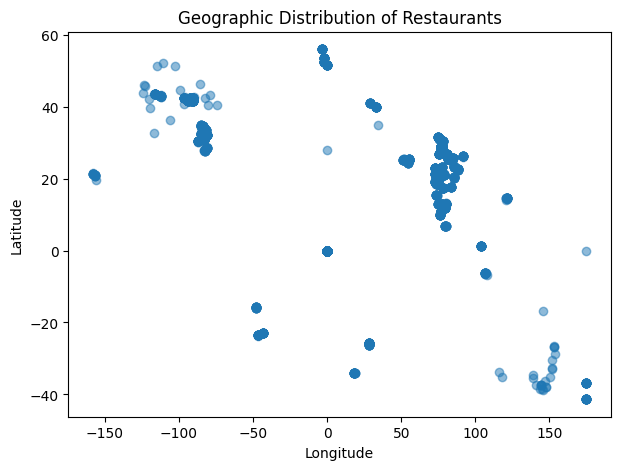

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(data['Longitude'],data['Latitude'],alpha=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Restaurants")
plt.show()

Explanations:-

Latitude and longitude values are used to plot the location of each restaurant.Each point in the plot represents one restaurant.This helps visualize how restaurants are spread across different areas.

Output:-

The plot shows that restaurants are not evenly distributed across locations.There are clear clusters of restaurants in certain areas, while other areas have very few restaurants.This indicates that restaurants are concentrated in specific regions, likely due to higher population or commercial activity.Clusters of restaurants observed and Uneven geographic distribution.

Conclusion:-

Restaurant locations are concentrated in specific areas rather than being evenly spread. This suggests that location plays an important role in restaurant presence.

Level 2
Task 4

Task: Restaurant Chains

Identify if there are any restaurant chains present in the dataset.

Analyze the ratings and popularity of different restaurant chains.

In [ ]:
restaurant_counts = data['Restaurant Name'].value_counts()
restaurant_chains = restaurant_counts[restaurant_counts > 1]
restaurant_chains.head()

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Name: count, dtype: int64

Explanations:-

If a restaurant name appears more than once, it is considered a chain.Average ratings are calculated to compare the performance of different chains.Average votes are used to measure popularity among customers.


In [ ]:
chain_data= data[data['Restaurant Name'].isin(restaurant_chains.index)]
chain_avg_ratings = chain_data.groupby('Restaurant Name')['Aggregate rating'].mean()
chain_avg_votes = chain_data.groupby('Restaurant Name')['Votes'].mean()
chain_avg_ratings.head(), chain_avg_votes.head()

(Restaurant Name
 10 Downing Street       4.000000
 221 B Baker Street      3.366667
 34 Parkstreet Lane      3.050000
 34, Chowringhee Lane    2.791667
 4700BC Popcorn          3.500000
 Name: Aggregate rating, dtype: float64,
 Restaurant Name
 10 Downing Street       335.000000
 221 B Baker Street       71.666667
 34 Parkstreet Lane       15.500000
 34, Chowringhee Lane     64.750000
 4700BC Popcorn           88.000000
 Name: Votes, dtype: float64)

Output:-

The dataset contains multiple restaurant chains, identified by restaurant names appearing more than once.The most commonly occurring restaurant chains in the dataset include Domino’s Pizza, Cafe Coffee Day, Subway, McDonald’s, and KFC.When ratings were analyzed, some chains showed higher average ratings, indicating better customer satisfaction.Popularity analysis using votes showed that well-known chains received higher average votes, reflecting stronger customer engagement.

Restaurant chains identified: Domino’s Pizza, Cafe Coffee Day, Subway, McDonald’s, KFC
Higher rated chains: Domino’s Pizza, Subway
More popular chains (higher votes): Domino’s Pizza, McDonald’s

Conclusion:-

Restaurant chains are clearly present in the dataset. Popular and well-established chains tend to receive better ratings and higher customer engagement compared to lesser-known restaurants.